In [4]:
#import pandas as pd
#
#df = pd.read_excel(
#    r"D:\project\ITI_Graduation_project\New Cairo KPIs.xlsx"
#)
#print(df.head())      # First 5 rows
#print(df.columns)     # Column names
#print(df.shape)       # Rows and columns

In [5]:
#import pandas as pd
#
#df = pd.read_excel(
#    "New Cairo KPIs.xlsx",
##    nrows=5
#)
#
#print(df.columns.tolist())

        Date             eNodeB Name     Cell Name  LocalCell Id  \
0 2026-04-19  LCAIN10118_CITY center  LCAIN10118-1             1   
1 2026-04-19  LCAIN10118_CITY center  LCAIN10118-2             2   
2 2026-04-19  LCAIN10118_CITY center  LCAIN10118-3             3   
3 2026-04-19  LCAIN10118_CITY center  LCAIN10118-5             5   
4 2026-04-19  LCAIN10118_CITY center  LCAIN10118-6             6   

   DL_Throughput  
0         8.8224  
1         6.4296  
2        17.2180  
3        18.6664  
4        17.7591  
(37044, 5)
count    37044.000000
mean        16.812752
std          4.720256
min          0.662900
25%         13.680750
50%         16.670750
75%         19.660475
max         67.443500
Name: DL_Throughput, dtype: float64
Unique Cells: 1300

Selected Cell: LCAIN10118-1
           Date  DL_Throughput
0    2026-04-19         8.8224
1220 2026-04-20        14.4678
2434 2026-04-21        10.5896
3606 2026-04-22        11.4372
4796 2026-04-23        11.8430


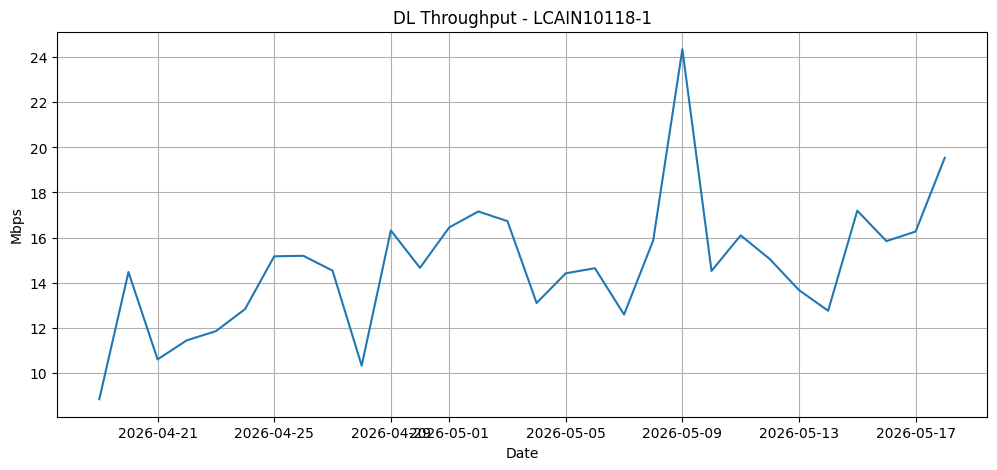

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

FILE = r"D:\project\ITI_Graduation_project\New Cairo KPIs.xlsx"

# Columns needed for the project
COLS = [
    "Date",
    "eNodeB Name",
    "Cell Name",
    "LocalCell Id",
    "(HU) Cell DL Average Throughput (Mbps)"
]

# Read only required columns
df = pd.read_excel(
    FILE,
    usecols=COLS
)

# Rename for easier coding
df = df.rename(columns={
    "(HU) Cell DL Average Throughput (Mbps)": "DL_Throughput"
})

# Convert date
df["Date"] = pd.to_datetime(df["Date"])

# Remove rows with missing throughput
df = df.dropna(subset=["DL_Throughput"])

print(df.head())
print(df.shape)

# Basic statistics
print(df["DL_Throughput"].describe())

# Number of cells
print("Unique Cells:", df["Cell Name"].nunique())

# Select one cell for forecasting
cell_name = df["Cell Name"].iloc[0]

cell_df = (
    df[df["Cell Name"] == cell_name]
    .sort_values("Date")
)

print(f"\nSelected Cell: {cell_name}")
print(cell_df[["Date", "DL_Throughput"]].head())

# Plot
plt.figure(figsize=(12,5))
plt.plot(
    cell_df["Date"],
    cell_df["DL_Throughput"]
)
plt.title(f"DL Throughput - {cell_name}")
plt.xlabel("Date")
plt.ylabel("Mbps")
plt.grid(True)
plt.show()

In [7]:
cell_counts = (
    df.groupby("Cell Name")
      .size()
      .sort_values(ascending=False)
)

print(cell_counts.head(20))

Cell Name
LCAIN22701-8    30
LCAIN22701-7    30
LCAIN16546-7    30
LCAIN16546-6    30
LCAIN16546-5    30
LCAIN16546-3    30
LCAIN16546-2    30
LCAIN16546-1    30
LCAIN15458-7    30
LCAIN15458-6    30
LCAIN15458-5    30
LCAIN15458-3    30
LCAIN15458-2    30
LCAIN15458-1    30
LCAIN15444-7    30
LCAIN15444-6    30
LCAIN10022-2    30
LCAIN10022-1    30
LCAIN10021-7    30
LCAIN10021-6    30
dtype: int64


In [8]:
# Select one cell
cell_name = df["Cell Name"].iloc[0]

cell_df = (
    df[df["Cell Name"] == cell_name]
    .sort_values("Date")
    .copy()
)

cell_df = cell_df[["Date", "DL_Throughput"]]

print(cell_df.head())

           Date  DL_Throughput
0    2026-04-19         8.8224
1220 2026-04-20        14.4678
2434 2026-04-21        10.5896
3606 2026-04-22        11.4372
4796 2026-04-23        11.8430


In [9]:
window = 3

cell_df["MA_Prediction"] = (
    cell_df["DL_Throughput"]
    .rolling(window=window)
    .mean()
    .shift(1)
)

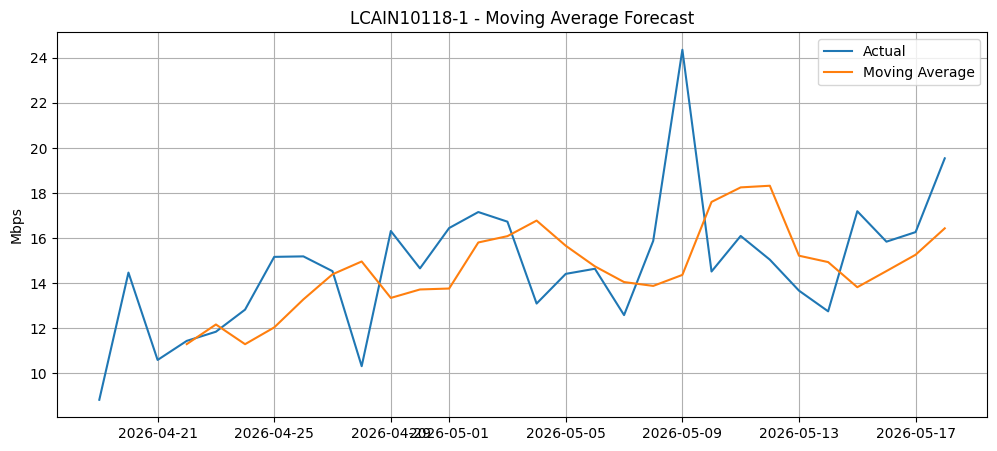

In [10]:
plt.figure(figsize=(12,5))

plt.plot(
    cell_df["Date"],
    cell_df["DL_Throughput"],
    label="Actual"
)

plt.plot(
    cell_df["Date"],
    cell_df["MA_Prediction"],
    label="Moving Average"
)

plt.title(f"{cell_name} - Moving Average Forecast")
plt.ylabel("Mbps")
plt.legend()
plt.grid(True)

plt.show()

In [11]:
from sklearn.metrics import mean_absolute_error

valid = cell_df.dropna()

mae = mean_absolute_error(
    valid["DL_Throughput"],
    valid["MA_Prediction"]
)

print("Moving Average MAE:", mae)

Moving Average MAE: 2.220875308641975


In [12]:
cell_df["Day"] = range(len(cell_df))

In [13]:
from sklearn.linear_model import LinearRegression

X = cell_df[["Day"]]
y = cell_df["DL_Throughput"]

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
cell_df["Trend_Prediction"] = model.predict(X)

In [15]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 0.1745284760845383
Intercept: 12.21431376344086


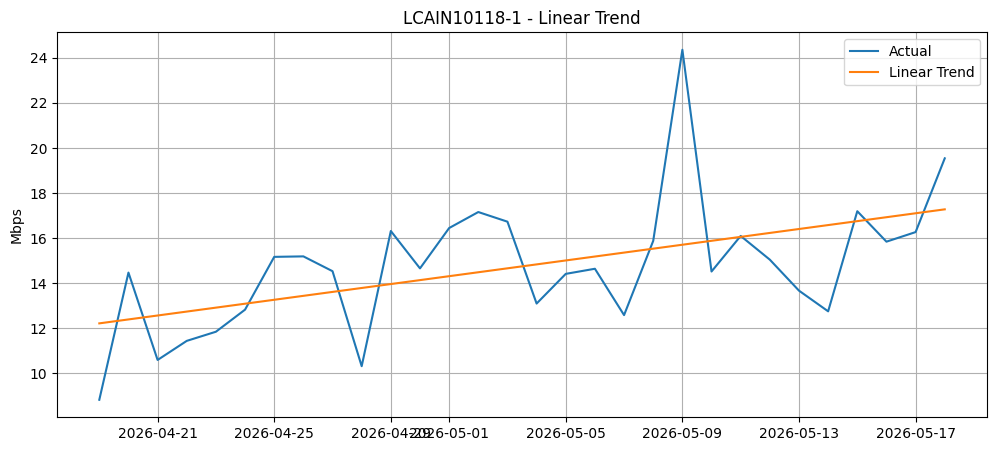

In [16]:
plt.figure(figsize=(12,5))

plt.plot(
    cell_df["Date"],
    cell_df["DL_Throughput"],
    label="Actual"
)

plt.plot(
    cell_df["Date"],
    cell_df["Trend_Prediction"],
    label="Linear Trend"
)

plt.title(f"{cell_name} - Linear Trend")
plt.ylabel("Mbps")
plt.legend()
plt.grid(True)

plt.show()

In [17]:
from sklearn.metrics import mean_absolute_error

mae_trend = mean_absolute_error(
    cell_df["DL_Throughput"],
    cell_df["Trend_Prediction"]
)

print("Linear Trend MAE:", mae_trend)


Linear Trend MAE: 1.877237936472624


In [18]:
# --- pick the same cell you used above ---
cell_name = df["Cell Name"].iloc[0]

cell_df = (
    df[df["Cell Name"] == cell_name]
    .groupby("Date")["DL_Throughput"]
    .mean()
    .reset_index()
    .sort_values("Date")
    .set_index("Date")
)

# Fill any gaps in the date index (ARIMA needs a continuous series)
cell_df = cell_df.asfreq("D", method="ffill")

print(f"Cell : {cell_name}")
print(f"Points: {len(cell_df)}")
print(cell_df.head())


Cell : LCAIN10118-1
Points: 30
            DL_Throughput
Date                     
2026-04-19         8.8224
2026-04-20        14.4678
2026-04-21        10.5896
2026-04-22        11.4372
2026-04-23        11.8430


In [19]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(cell_df["DL_Throughput"].dropna())

print("ADF Statistic :", round(result[0], 4))
print("p-value       :", round(result[1], 4))
print()
if result[1] < 0.05:
    print("Series is STATIONARY (p < 0.05) → use d=0")
else:
    print("Series is NON-STATIONARY (p >= 0.05) → use d=1")
    

ADF Statistic : -3.4223
p-value       : 0.0102

Series is STATIONARY (p < 0.05) → use d=0


Train: 23 days  |  Test: 7 days


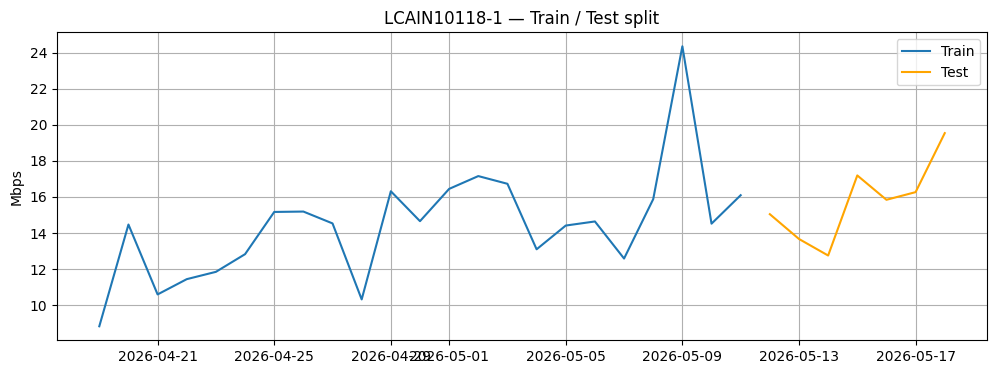

In [20]:
import matplotlib.pyplot as plt

FORECAST_HORIZON = 7   # days to hold out for testing

train = cell_df.iloc[:-FORECAST_HORIZON]
test  = cell_df.iloc[-FORECAST_HORIZON:]

print(f"Train: {len(train)} days  |  Test: {len(test)} days")

plt.figure(figsize=(12, 4))
plt.plot(train["DL_Throughput"], label="Train")
plt.plot(test["DL_Throughput"],  label="Test", color="orange")
plt.title(f"{cell_name} — Train / Test split")
plt.ylabel("Mbps")
plt.legend()
plt.grid(True)
plt.show()

ARIMA MAE: 1.9543


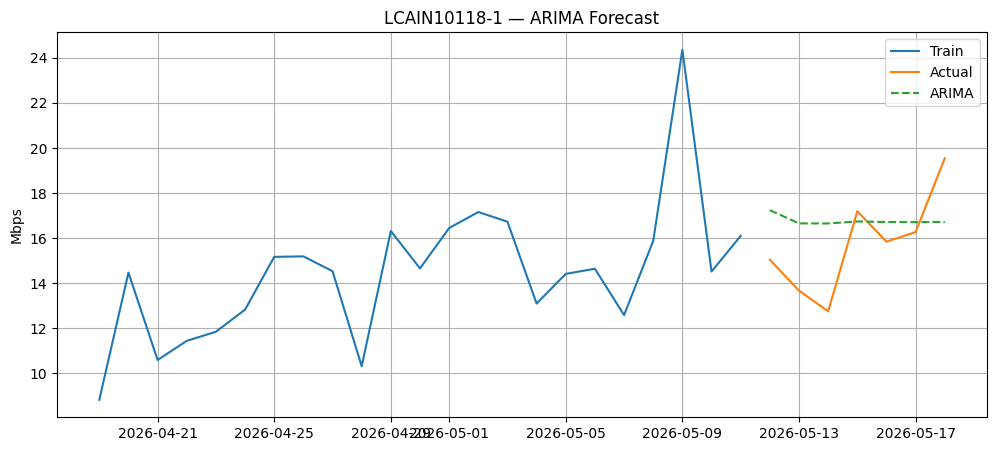

In [21]:
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

arima_fit = ARIMA(train["DL_Throughput"], order=(2, 1, 2)).fit()
arima_forecast = arima_fit.forecast(steps=FORECAST_HORIZON)

mae = mean_absolute_error(test["DL_Throughput"], arima_forecast)
print("ARIMA MAE:", round(mae, 4))

plt.figure(figsize=(12, 5))
plt.plot(train.index, train["DL_Throughput"], label="Train")
plt.plot(test.index,  test["DL_Throughput"],  label="Actual")
plt.plot(test.index,  arima_forecast.values,  label="ARIMA", linestyle="--")
plt.title(f"{cell_name} — ARIMA Forecast")
plt.ylabel("Mbps")
plt.legend()
plt.grid(True)
plt.show()

SARIMA MAE: 2.6405


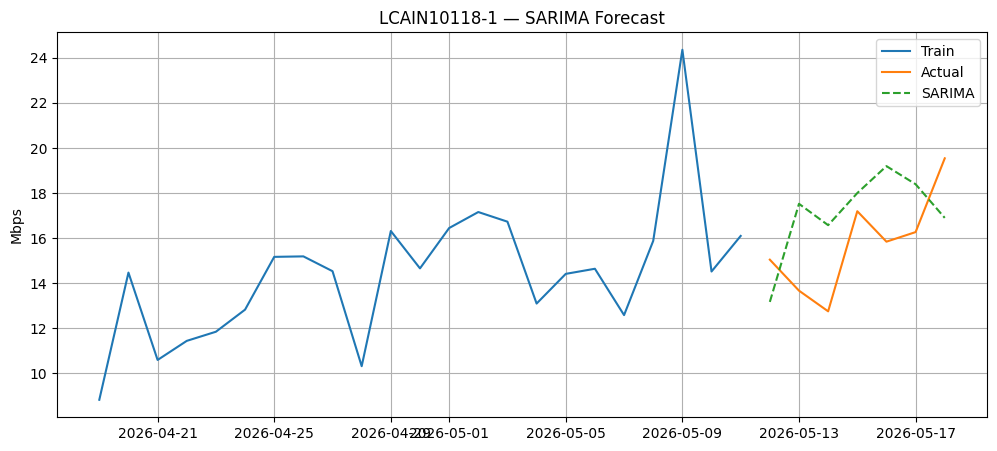

In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_fit = SARIMAX(
    train["DL_Throughput"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_forecast = sarima_fit.forecast(steps=FORECAST_HORIZON)

mae = mean_absolute_error(test["DL_Throughput"], sarima_forecast)
print("SARIMA MAE:", round(mae, 4))

plt.figure(figsize=(12, 5))
plt.plot(train.index, train["DL_Throughput"],  label="Train")
plt.plot(test.index,  test["DL_Throughput"],   label="Actual")
plt.plot(test.index,  sarima_forecast.values,  label="SARIMA", linestyle="--")
plt.title(f"{cell_name} — SARIMA Forecast")
plt.ylabel("Mbps")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# try these orders and compare MAE
ARIMA(train["DL_Throughput"], order=(1, 1, 1)).fit()
ARIMA(train["DL_Throughput"], order=(3, 1, 2)).fit()

In [24]:
q_low  = train["DL_Throughput"].quantile(0.05)
q_high = train["DL_Throughput"].quantile(0.95)
train_clean = train["DL_Throughput"].clip(q_low, q_high)

# then fit on train_clean instead of train["DL_Throughput"]

In [25]:
%pip install pmdarima

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
from pmdarima import auto_arima

model = auto_arima(
    train["DL_Throughput"],
    seasonal=True, m=7,
    stepwise=True,
    information_criterion="aic",
    trace=True          # prints what it's testing
)
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[7] intercept   : AIC=inf, Time=0.91 sec
 ARIMA(0,0,0)(0,1,0)[7] intercept   : AIC=83.782, Time=0.01 sec
 ARIMA(1,0,0)(1,1,0)[7] intercept   : AIC=84.977, Time=0.12 sec
 ARIMA(0,0,1)(0,1,1)[7] intercept   : AIC=inf, Time=0.44 sec
 ARIMA(0,0,0)(0,1,0)[7]             : AIC=86.468, Time=0.01 sec
 ARIMA(0,0,0)(1,1,0)[7] intercept   : AIC=84.967, Time=0.08 sec
 ARIMA(0,0,0)(0,1,1)[7] intercept   : AIC=inf, Time=0.40 sec
 ARIMA(0,0,0)(1,1,1)[7] intercept   : AIC=inf, Time=0.38 sec
 ARIMA(1,0,0)(0,1,0)[7] intercept   : AIC=84.359, Time=0.03 sec
 ARIMA(0,0,1)(0,1,0)[7] intercept   : AIC=84.155, Time=0.06 sec
 ARIMA(1,0,1)(0,1,0)[7] intercept   : AIC=86.146, Time=0.09 sec

Best model:  ARIMA(0,0,0)(0,1,0)[7] intercept
Total fit time: 2.558 seconds
                                SARIMAX Results                                
Dep. Variable:                       y   No. Observations:                   23
Model:             SARIMAX(0

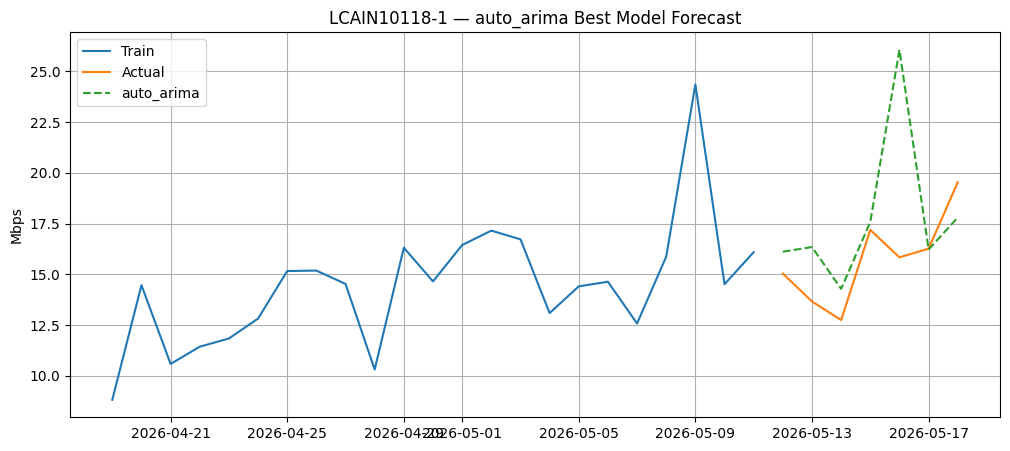

MAE: 2.5278


In [27]:

forecast = model.predict(n_periods=7)

plt.figure(figsize=(12, 5))
plt.plot(train.index, train["DL_Throughput"], label="Train")
plt.plot(test.index,  test["DL_Throughput"],  label="Actual")
plt.plot(test.index,  forecast,               label="auto_arima", linestyle="--")
plt.title(f"{cell_name} — auto_arima Best Model Forecast")
plt.ylabel("Mbps")
plt.legend()
plt.grid(True)
plt.show()

from sklearn.metrics import mean_absolute_error
print("MAE:", round(mean_absolute_error(test["DL_Throughput"], forecast), 4))

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=1.09 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=109.170, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=106.276, Time=0.10 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=inf, Time=0.35 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=107.512, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=104.778, Time=0.03 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=106.089, Time=0.08 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=inf, Time=0.39 sec
 ARIMA(2,1,0)(0,0,0)[7] intercept   : AIC=105.048, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(2,1,1)(0,0,0)[7] intercept   : AIC=inf, Time=0.20 sec
 ARIMA(1,1,0)(0,0,0)[7]             : AIC=103.260, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[7]             : AIC=104.734, Time=0.06 sec
 ARIMA(1,1,0)(0,0,1)[7]             : AIC=104.562, Time=0.07 sec
 ARIMA

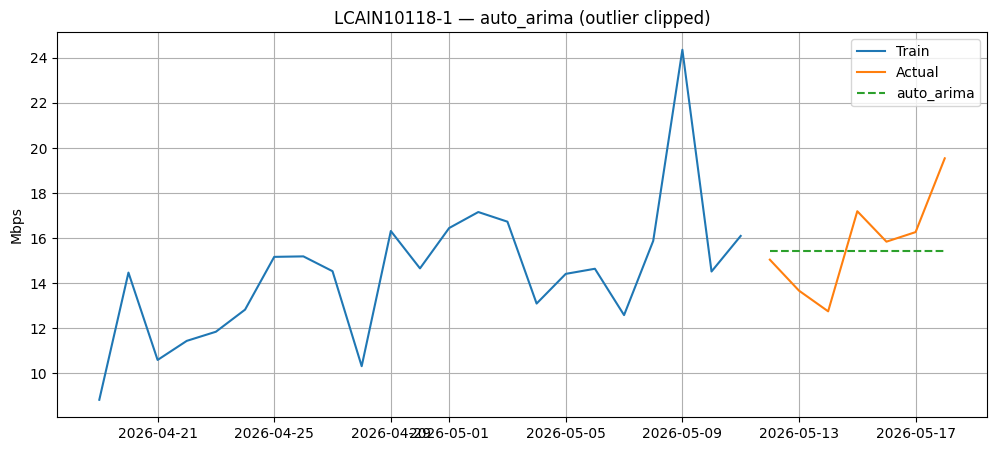

MAE: 1.7062


In [28]:
q_high = train["DL_Throughput"].quantile(0.95)
train_clipped = train["DL_Throughput"].clip(upper=q_high)

model = auto_arima(
    train_clipped,
    seasonal=True, m=7,
    stepwise=True,
    information_criterion="aic",
    trace=True
)

forecast = model.predict(n_periods=7)

plt.figure(figsize=(12, 5))
plt.plot(train.index, train["DL_Throughput"], label="Train")   # original for display
plt.plot(test.index,  test["DL_Throughput"],  label="Actual")
plt.plot(test.index,  forecast,               label="auto_arima", linestyle="--")
plt.title(f"{cell_name} — auto_arima (outlier clipped)")
plt.ylabel("Mbps")
plt.legend()
plt.grid(True)
plt.show()

print("MAE:", round(mean_absolute_error(test["DL_Throughput"], forecast), 4))

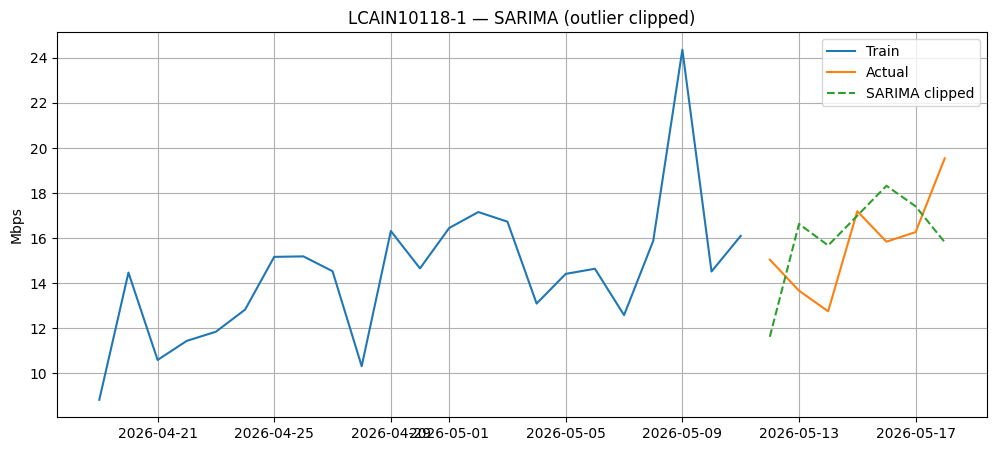

MAE: 2.4088


In [29]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_fit = SARIMAX(
    train_clipped,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

forecast = sarima_fit.forecast(steps=7)

plt.figure(figsize=(12, 5))
plt.plot(train.index, train["DL_Throughput"], label="Train")
plt.plot(test.index,  test["DL_Throughput"],  label="Actual")
plt.plot(test.index,  forecast,               label="SARIMA clipped", linestyle="--")
plt.title(f"{cell_name} — SARIMA (outlier clipped)")
plt.ylabel("Mbps")
plt.legend()
plt.grid(True)
plt.show()

print("MAE:", round(mean_absolute_error(test["DL_Throughput"], forecast), 4))

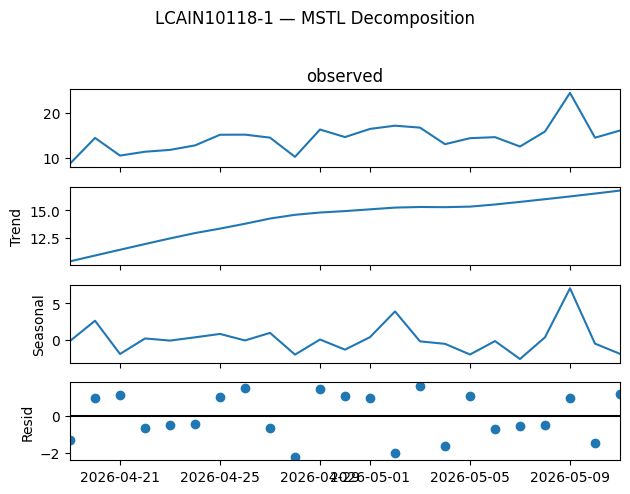

In [30]:
from statsmodels.tsa.seasonal import MSTL

decomp = MSTL(train["DL_Throughput"], periods=[7]).fit()

decomp.plot()
plt.suptitle(f"{cell_name} — MSTL Decomposition", y=1.02)
plt.tight_layout()
plt.show()

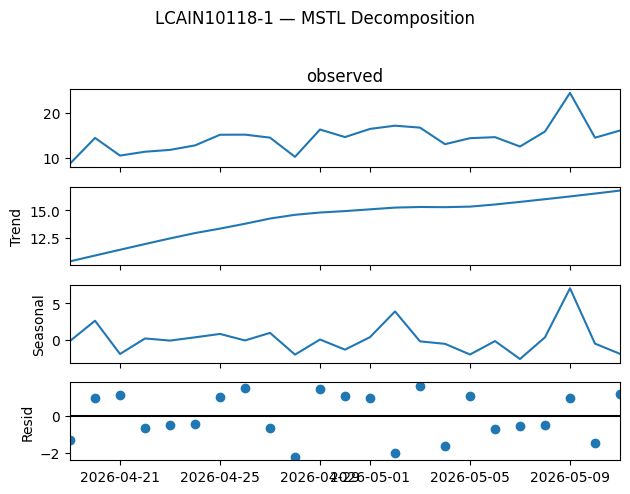

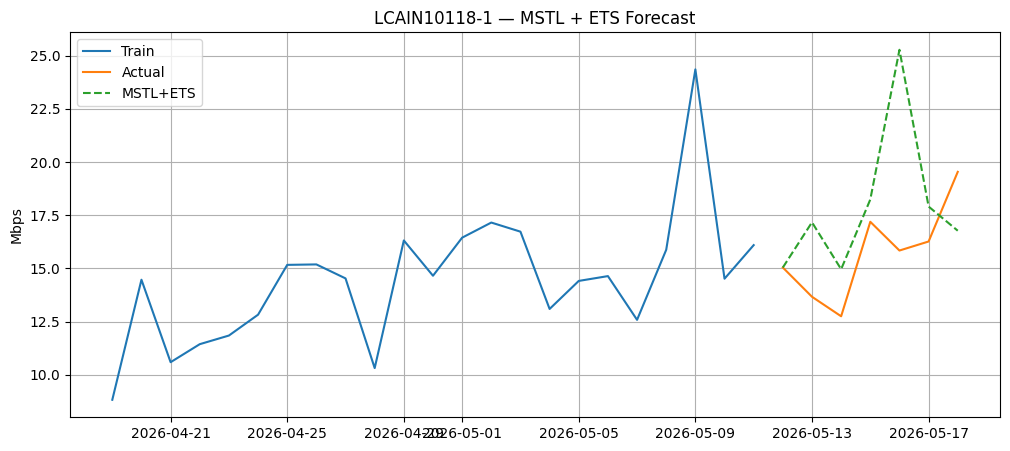

MAE: 2.9452


In [31]:
from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

# Decompose
decomp   = MSTL(train["DL_Throughput"], periods=[7]).fit()
trend    = decomp.trend
seasonal = decomp.seasonal

# Plot decomposition
decomp.plot()
plt.suptitle(f"{cell_name} — MSTL Decomposition", y=1.02)
plt.tight_layout()
plt.show()

# Forecast trend with ETS, add last seasonal cycle back
ets_fit        = ETSModel(trend.dropna(), error="add", trend="add").fit(disp=False)
trend_forecast = ets_fit.forecast(7)
last_seasonal  = seasonal.values[-7:]

forecast_vals = trend_forecast.values + last_seasonal

plt.figure(figsize=(12, 5))
plt.plot(train.index, train["DL_Throughput"], label="Train")
plt.plot(test.index,  test["DL_Throughput"],  label="Actual")
plt.plot(test.index,  forecast_vals,          label="MSTL+ETS", linestyle="--")
plt.title(f"{cell_name} — MSTL + ETS Forecast")
plt.ylabel("Mbps")
plt.legend()
plt.grid(True)
plt.show()

print("MAE:", round(mean_absolute_error(test["DL_Throughput"], forecast_vals), 4))

In [37]:
def make_features(series, lags=[1, 2, 3, 7]):
    df_feat = pd.DataFrame({"y": series})
    for lag in lags:
        df_feat[f"lag_{lag}"] = df_feat["y"].shift(lag)
    df_feat["day_of_week"] = series.index.dayofweek
    return df_feat.dropna()

features = make_features(cell_df["DL_Throughput"])
print(features.head())

                  y    lag_1    lag_2    lag_3    lag_7  day_of_week
Date                                                                
2026-04-26  15.1879  15.1663  12.8239  11.8430   8.8224            6
2026-04-27  14.5304  15.1879  15.1663  12.8239  14.4678            0
2026-04-28  10.3131  14.5304  15.1879  15.1663  10.5896            1
2026-04-29  16.3143  10.3131  14.5304  15.1879  11.4372            2
2026-04-30  14.6550  16.3143  10.3131  14.5304  11.8430            3


MAE: 2.9785


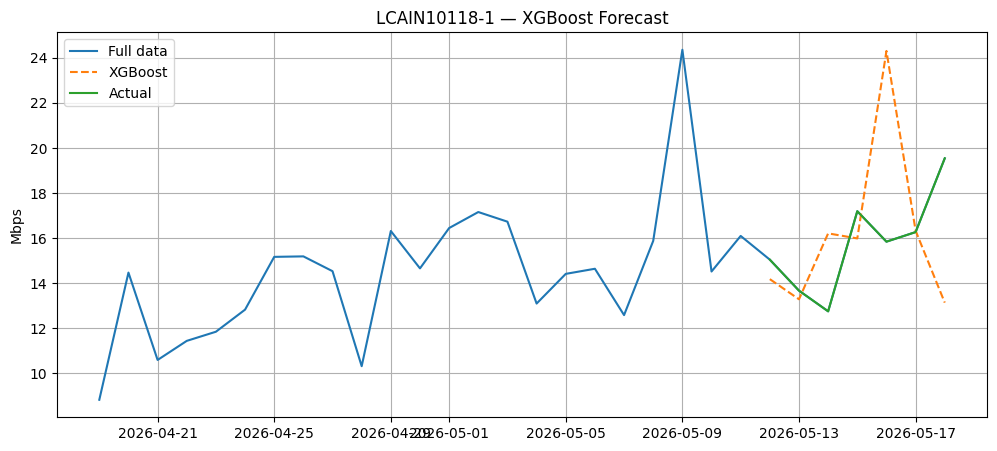

In [38]:
import xgboost as xgb

split = len(features) - 7

X_train = features.iloc[:split].drop(columns="y")
y_train = features.iloc[:split]["y"]
X_test  = features.iloc[split:].drop(columns="y")
y_test  = features.iloc[split:]["y"]

model_xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_xgb.fit(X_train, y_train)

forecast_vals = model_xgb.predict(X_test)

print("MAE:", round(mean_absolute_error(y_test, forecast_vals), 4))

plt.figure(figsize=(12, 5))
plt.plot(cell_df.index, cell_df["DL_Throughput"], label="Full data")
plt.plot(y_test.index,  forecast_vals,            label="XGBoost", linestyle="--")
plt.plot(y_test.index,  y_test,                   label="Actual")
plt.title(f"{cell_name} — XGBoost Forecast")
plt.ylabel("Mbps")
plt.legend()
plt.grid(True)
plt.show()

SARIMA (All Cells Avg) MAE: 0.4878


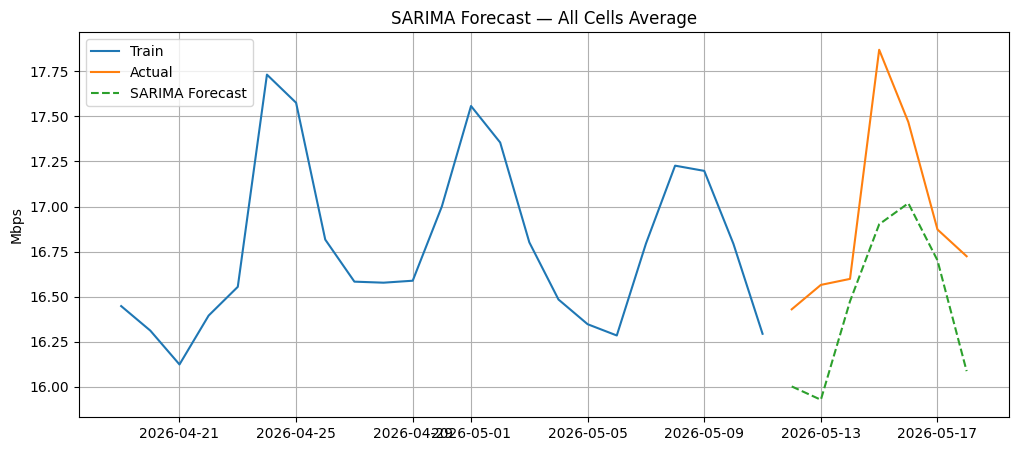

In [39]:
# --- SARIMA on ALL cells average ---

# Average DL_Throughput across all cells per day
all_cells_avg = (
    df.groupby("Date")["DL_Throughput"]
    .mean()
    .sort_index()
    .asfreq("D", method="ffill")
)

# Train/test split
train_avg = all_cells_avg.iloc[:-7]
test_avg  = all_cells_avg.iloc[-7:]

# Fit SARIMA
sarima_all = SARIMAX(
    train_avg,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

forecast_avg = sarima_all.forecast(steps=7)

print("SARIMA (All Cells Avg) MAE:", round(mean_absolute_error(test_avg, forecast_avg), 4))

plt.figure(figsize=(12, 5))
plt.plot(train_avg.index, train_avg,       label="Train")
plt.plot(test_avg.index,  test_avg,        label="Actual")
plt.plot(test_avg.index,  forecast_avg,    label="SARIMA Forecast", linestyle="--")
plt.title("SARIMA Forecast — All Cells Average")
plt.ylabel("Mbps")
plt.legend()
plt.grid(True)
plt.show()